In [1]:
import numpy as np, tools_multitracer as mass, pickle, curvedsky as cs, healpy as hp, local, tqdm
from matplotlib.pyplot import *

In [2]:
import importlib
importlib.reload(local)

<module 'local' from '/global/u1/t/toshiyan/Work/Ongoing/litebird/project-lens/local.py'>

In [3]:
lmax = 1024
simn = 20
ctypes = ['klb','cib','gal','ext','all']
glob  = local.analysis()

In [4]:
xcl, acl, rho = {}, {}, {}
for ctype in ctypes:
    xcl[ctype] = np.zeros((simn,lmax+1))
    acl[ctype] = np.zeros((simn,lmax+1))
    rho[ctype] = np.zeros((simn,lmax+1))
    for rlz in tqdm.tqdm(range(simn)):
        iklm  = glob.load_input_kappa(rlz+1,lmax)
        mobj = mass.comb_mobj(ctype,lmax=lmax)
        klm = pickle.load(open(mobj.fwklm[rlz+1],"rb"))
        kcl = cs.utils.alm2cl(lmax,iklm)
        xcl[ctype][rlz,:] = cs.utils.alm2cl(lmax,iklm,klm)
        acl[ctype][rlz,:] = cs.utils.alm2cl(lmax,klm)
        rho[ctype][rlz,:] = xcl[ctype][rlz,:]/np.sqrt(acl[ctype][rlz,:]*kcl)

  0%|          | 0/20 [00:00<?, ?it/s]/tmp/ipykernel_46359/905642716.py:13: RuntimeWarning: invalid value encountered in true_divide
  rho[ctype][rlz,:] = xcl[ctype][rlz,:]/np.sqrt(acl[ctype][rlz,:]*kcl)
100%|██████████| 20/20 [00:33<00:00,  1.69s/it]


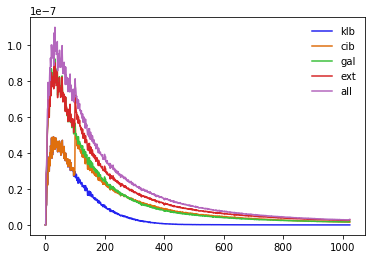

In [5]:
for ctype in ctypes:
    mxcl = np.mean(xcl[ctype],axis=0)
    plot(mxcl,label=ctype)
legend()

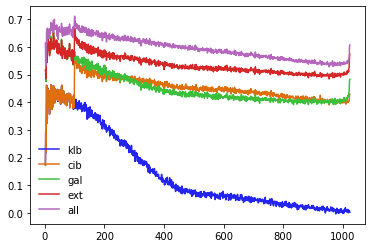

In [6]:
for ctype in ctypes:
    mrho = np.mean(rho[ctype],axis=0)
    plot(mrho,label=ctype)
legend()